# Lab 3 - Part 2: Word and Sentence Embeddings

**Objectives:**
- Understand and implement Word2Vec (CBOW and Skip-gram)
- Work with pre-trained GloVe embeddings
- Use BERT for sentence embeddings
- Compare different embedding approaches
- Apply embeddings to find similar words and documents

---

You will use the same dataset and categories you chose in Part 1.

---

## Setup

In [55]:
# Install required libraries (uncomment if needed)
!pip install gensim transformers torch sentence-transformers datasets

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re
import string
import warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt_tab', quiet=True) # Added to fix the LookupError

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import gensim
from gensim.models import Word2Vec, KeyedVectors
import gensim.downloader as api

print(f"Gensim version: {gensim.__version__}")
print("Setup complete!")

Gensim version: 4.4.0
Setup complete!


## Load Dataset (Same as Part 1)

In [57]:
import pandas as pd
from datasets import load_dataset

# Load the dataset
raw_datasets = load_dataset('SetFit/20_newsgroups')
# Assuming you want to use the 'train' split
df = raw_datasets['train'].to_pandas()

# TODO: Use the SAME 3 categories you chose in Part 1!
my_categories = ["rec.autos", "sci.space", "talk.politics.guns"]

# Filter dataset
df_filtered = df[df['label_text'].isin(my_categories)].copy()
df_filtered = df_filtered.reset_index(drop=True)

print(f"Selected categories: {my_categories}")
print(f"Filtered dataset size: {len(df_filtered)}")

Repo card metadata block was not found. Setting CardData to empty.


Selected categories: ['rec.autos', 'sci.space', 'talk.politics.guns']
Filtered dataset size: 1733


In [58]:
# Preprocessing function (same as Part 1)
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    """Preprocess text for embedding training."""
    # Convert to lowercase
    text = text.lower()
    # Remove punctuation
    text = re.sub(f'[{re.escape(string.punctuation)}]', '', text)
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Tokenize
    tokens = word_tokenize(text)
    # Remove stopwords and non-alphabetic tokens, then lemmatize
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word.isalpha() and word not in stop_words]
    return tokens  # Return list of tokens for Word2Vec

# Apply preprocessing
df_filtered['tokens'] = df_filtered['text'].apply(preprocess_text)
df_filtered['text_clean'] = df_filtered['tokens'].apply(' '.join)

print(f"Sample tokens: {df_filtered.iloc[0]['tokens'][:20]}")

Sample tokens: ['wondering', 'anyone', 'could', 'enlighten', 'car', 'saw', 'day', 'door', 'sport', 'car', 'looked', 'late', 'early', 'called', 'bricklin', 'door', 'really', 'small', 'addition', 'front']


In [59]:
import re
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    """Preprocess text for embedding training."""
    # Convert to lowercase
    text = text.lower()
    # Remove punctuation
    text = re.sub(f'[{re.escape(string.punctuation)}]', '', text)
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Tokenize
    tokens = word_tokenize(text)
    # Remove stopwords and non-alphabetic tokens, then lemmatize
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word.isalpha() and word not in stop_words]
    return tokens

    # Apply preprocessing
df_filtered['tokens'] = df_filtered['text'].apply(preprocess_text)
df_filtered['text_clean'] = df_filtered['tokens'].apply(' '.join)

print(f"Sample tokens: {df_filtered.iloc[0]['tokens'][:20]}")

Sample tokens: ['wondering', 'anyone', 'could', 'enlighten', 'car', 'saw', 'day', 'door', 'sport', 'car', 'looked', 'late', 'early', 'called', 'bricklin', 'door', 'really', 'small', 'addition', 'front']


---

## Part A: Word2Vec - Training Your Own Embeddings

Word2Vec learns word representations by predicting context. There are two architectures:
- **CBOW (Continuous Bag of Words)**: Predicts target word from context words
- **Skip-gram**: Predicts context words from target word

### A.1 Understanding Word2Vec Architectures

In [60]:
# Prepare corpus for Word2Vec (list of tokenized sentences)
corpus = df_filtered['tokens'].tolist()

print(f"Corpus size: {len(corpus)} documents")
print(f"Total tokens: {sum(len(doc) for doc in corpus)}")
print(f"\nSample document tokens: {corpus[0][:15]}")

Corpus size: 1733 documents
Total tokens: 164435

Sample document tokens: ['wondering', 'anyone', 'could', 'enlighten', 'car', 'saw', 'day', 'door', 'sport', 'car', 'looked', 'late', 'early', 'called', 'bricklin']


In [61]:
# Train Word2Vec with CBOW (sg=0)
model_cbow = Word2Vec(
    sentences=corpus,
    vector_size=100,      # Embedding dimension
    window=5,             # Context window size
    min_count=5,          # Ignore words with freq < 5
    workers=4,            # Parallel threads
    sg=0,                 # 0 = CBOW, 1 = Skip-gram
    epochs=10             # Training epochs
)

print(f"CBOW Model trained!")
print(f"Vocabulary size: {len(model_cbow.wv)}")

CBOW Model trained!
Vocabulary size: 4943


In [62]:
# Train Word2Vec with Skip-gram (sg=1)
model_skipgram = Word2Vec(
    sentences=corpus,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4,
    sg=1,                 # Skip-gram
    epochs=10
)

print(f"Skip-gram Model trained!")
print(f"Vocabulary size: {len(model_skipgram.wv)}")

Skip-gram Model trained!
Vocabulary size: 4943


### A.2 Exploring Word Embeddings

In [63]:
# Example: Get word vector
sample_word = "computer"  # Change this to a word relevant to YOUR categories

if sample_word in model_cbow.wv:
    vector = model_cbow.wv[sample_word]
    print(f"Vector for '{sample_word}':")
    print(f"  Shape: {vector.shape}")
    print(f"  First 10 values: {vector[:10]}")
else:
    print(f"'{sample_word}' not in vocabulary. Try another word.")
    print(f"Sample words in vocab: {list(model_cbow.wv.key_to_index.keys())[:20]}")

Vector for 'computer':
  Shape: (100,)
  First 10 values: [-0.31236795  0.35893768  0.03462451 -0.08413205  0.03153991 -0.6686848
  0.03789753  0.67931545 -0.11734226  0.11341148]


In [64]:
# Find similar words
sample_word = "computer"  # Change to a word in YOUR vocabulary

if sample_word in model_cbow.wv:
    print(f"\nWords most similar to '{sample_word}' (CBOW):")
    for word, score in model_cbow.wv.most_similar(sample_word, topn=10):
        print(f"  {word}: {score:.4f}")

    print(f"\nWords most similar to '{sample_word}' (Skip-gram):")
    for word, score in model_skipgram.wv.most_similar(sample_word, topn=10):
        print(f"  {word}: {score:.4f}")


Words most similar to 'computer' (CBOW):
  processing: 0.9982
  handbook: 0.9979
  engineering: 0.9976
  advanced: 0.9973
  rockwell: 0.9973
  global: 0.9973
  bulletin: 0.9973
  douglas: 0.9972
  communication: 0.9972
  dynamic: 0.9971

Words most similar to 'computer' (Skip-gram):
  algorithm: 0.8636
  processing: 0.8578
  simulation: 0.8572
  astrophysics: 0.8547
  electronic: 0.8543
  starcat: 0.8536
  interactive: 0.8510
  ephemeris: 0.8485
  nssdc: 0.8476
  eugene: 0.8444


### Exercise A.1: Compare CBOW vs Skip-gram

Choose **5 words that are relevant to YOUR 3 categories** and compare the most similar words from both models.

In [65]:
# TODO: Choose 5 words relevant to YOUR categories
# These should be domain-specific words (not common words like "good", "make", etc.)

my_test_words = ["computer", "space", "gun", "engine", "nasa"]

comparison_results = []

for word in my_test_words:
    word = word.lower()
    if word in model_cbow.wv and word in model_skipgram.wv:
        cbow_similar = [w for w, s in model_cbow.wv.most_similar(word, topn=5)]
        skipgram_similar = [w for w, s in model_skipgram.wv.most_similar(word, topn=5)]

        comparison_results.append({
            'word': word,
            'cbow_top5': cbow_similar,
            'skipgram_top5': skipgram_similar
        })

        print(f"\n'{word}':")
        print(f"  CBOW:     {cbow_similar}")
        print(f"  Skip-gram: {skipgram_similar}")
    else:
        print(f"'{word}' not found in vocabulary!")


'computer':
  CBOW:     ['processing', 'handbook', 'engineering', 'advanced', 'rockwell']
  Skip-gram: ['algorithm', 'processing', 'simulation', 'astrophysics', 'electronic']

'space':
  CBOW:     ['nasa', 'program', 'station', 'technology', 'shuttle']
  Skip-gram: ['nasajscgm', 'jenks', 'kjenksgothamcityjscnasagov', 'aerospace', 'telescope']

'gun':
  CBOW:     ['criminal', 'crime', 'death', 'police', 'case']
  Skip-gram: ['strict', 'illegally', 'riot', 'legally', 'stricter']

'engine':
  CBOW:     ['mile', 'light', 'around', 'k', 'fuel']
  Skip-gram: ['diesel', 'motor', 'impulse', 'gasoline', 'compartment']

'nasa':
  CBOW:     ['program', 'space', 'technology', 'station', 'center']
  Skip-gram: ['dryden', 'ames', 'shafer', 'langley', 'select']


### Written Question A.1 (Personal Interpretation)

Based on your comparison above:

1. **For which words did CBOW and Skip-gram give SIMILAR results?**
2. **For which words did they give DIFFERENT results?**
3. **Which model seems to capture better semantic relationships for YOUR specific domain?** Explain with examples.
4. **Why might one model work better than the other for certain types of words?** (Think about word frequency)

**YOUR ANSWER:**

1. Similar results for: ...

2. Different results for: ...

3. Better model for my domain: ...
   - Example 1: ...
   - Example 2: ...

4. Explanation of differences: ...

### A.3 Word Analogies

In [66]:
# Example: Word analogies (king - man + woman = queen)
# This works better with larger, pre-trained models, but let's try with our custom model

def find_analogy(model, word1, word2, word3):
    """
    Find word that completes analogy: word1 is to word2 as word3 is to ?
    Uses: word2 - word1 + word3 = ?
    """
    try:
        result = model.wv.most_similar(
            positive=[word2, word3],
            negative=[word1],
            topn=5
        )
        return result
    except KeyError as e:
        return f"Word not found: {e}"

# Test with your domain
# Example: "baseball" is to "bat" as "hockey" is to ?
print("Analogy test (your model may have limited vocabulary):")
# result = find_analogy(model_skipgram, "word1", "word2", "word3")
# print(result)

Analogy test (your model may have limited vocabulary):


### Exercise A.2: Create Domain-Specific Analogies

Try to find **2 analogies** that work with YOUR dataset's vocabulary.

In [67]:
# TODO: Try 2 analogies with words from YOUR vocabulary
# Format: word1 is to word2 as word3 is to ?

# Analogy 1
analogy1 = find_analogy(model_skipgram, "radar", "space", "nasa")
print(f"Analogy 1: {analogy1}")

# Analogy 2
analogy2 = find_analogy(model_skipgram, "car", "year", "speed")
print(f"Analogy 2: {analogy2}")

Analogy 1: [('administration', 0.5648782253265381), ('reston', 0.5636582970619202), ('dryden', 0.5550755262374878), ('mary', 0.548880934715271), ('budget', 0.546031653881073)]
Analogy 2: [('within', 0.5202344059944153), ('half', 0.5189279317855835), ('degree', 0.5178824663162231), ('leading', 0.49576666951179504), ('inclination', 0.49528488516807556)]


### Written Question A.2 (Personal Interpretation)

**Did your analogies work?**
- If yes, explain why the result makes sense.
- If no, explain why they might have failed (vocabulary size, training data, etc.)

**YOUR ANSWER:**

*[Analyze your analogy results]*

...

---

## Part B: Pre-trained GloVe Embeddings

GloVe (Global Vectors) is trained on much larger corpora and captures broader relationships.

In [68]:
# Load pre-trained GloVe embeddings (this may take a few minutes)
print("Loading GloVe embeddings (this may take a minute)...")
glove_model = api.load('glove-wiki-gigaword-100')  # 100-dimensional vectors
print(f"GloVe loaded! Vocabulary size: {len(glove_model)}")

Loading GloVe embeddings (this may take a minute)...
GloVe loaded! Vocabulary size: 400000


In [69]:
# Compare: Same word in YOUR model vs GloVe
test_word = "computer"  # Change to a word relevant to your domain

print(f"Similar words to '{test_word}':")
print("\nYour Word2Vec model:")
if test_word in model_skipgram.wv:
    for word, score in model_skipgram.wv.most_similar(test_word, topn=10):
        print(f"  {word}: {score:.4f}")
else:
    print(f"  '{test_word}' not in vocabulary")

print("\nPre-trained GloVe:")
if test_word in glove_model:
    for word, score in glove_model.most_similar(test_word, topn=10):
        print(f"  {word}: {score:.4f}")
else:
    print(f"  '{test_word}' not in vocabulary")

Similar words to 'computer':

Your Word2Vec model:
  algorithm: 0.8636
  processing: 0.8578
  simulation: 0.8572
  astrophysics: 0.8547
  electronic: 0.8543
  starcat: 0.8536
  interactive: 0.8510
  ephemeris: 0.8485
  nssdc: 0.8476
  eugene: 0.8444

Pre-trained GloVe:
  computers: 0.8752
  software: 0.8373
  technology: 0.7642
  pc: 0.7366
  hardware: 0.7290
  internet: 0.7287
  desktop: 0.7234
  electronic: 0.7222
  systems: 0.7198
  computing: 0.7142


### Exercise B.1: Compare Your Model vs GloVe

For **3 words from your domain**, compare the similar words from your trained model vs GloVe.

In [70]:
# TODO: Compare 3 domain-specific words

comparison_words = ["national", "oil", "system"]  # YOUR WORDS

for word in comparison_words:
    word = word.lower()
    print(f"\n{'='*50}")
    print(f"Word: '{word}'")
    print(f"{'='*50}")

    # Your model
    print("Your Word2Vec:")
    if word in model_skipgram.wv:
        for w, s in model_skipgram.wv.most_similar(word, topn=5):
            print(f"  {w}: {s:.3f}")
    else:
        print("  Not in vocabulary")

    # GloVe
    print("GloVe:")
    if word in glove_model:
        for w, s in glove_model.most_similar(word, topn=5):
            print(f"  {w}: {s:.3f}")
    else:
        print("  Not in vocabulary")


Word: 'national'
Your Word2Vec:
  administration: 0.812
  association: 0.785
  aeronautics: 0.779
  institute: 0.773
  nonprofit: 0.755
GloVe:
  state: 0.718
  public: 0.691
  association: 0.685
  the: 0.682
  international: 0.678

Word: 'oil'
Your Word2Vec:
  viscosity: 0.899
  hot: 0.837
  weight: 0.826
  rotor: 0.814
  winter: 0.806
GloVe:
  petroleum: 0.787
  crude: 0.778
  gas: 0.765
  fuel: 0.702
  energy: 0.686

Word: 'system'
Your Word2Vec:
  electrical: 0.651
  testbed: 0.626
  kernel: 0.625
  lp: 0.623
  solar: 0.620
GloVe:
  systems: 0.858
  control: 0.717
  program: 0.699
  which: 0.697
  using: 0.694


### Written Question B.1 (Personal Interpretation)

Compare your custom-trained Word2Vec model with pre-trained GloVe:

1. **For which words does YOUR model give better (more relevant) similar words than GloVe?** Why?
2. **For which words does GloVe give better results?** Why?
3. **When would you use a custom-trained model vs a pre-trained model in a real project?**

**YOUR ANSWER:**

1. My model is better for: ...
   - Reason: ...

2. GloVe is better for: ...
   - Reason: ...

3. When to use each:
   - Custom model: ...
   - Pre-trained model: ...

### B.2 GloVe Analogies

In [71]:
# Famous analogy: king - man + woman = queen
result = glove_model.most_similar(positive=['king', 'woman'], negative=['man'], topn=5)
print("king - man + woman = ?")
for word, score in result:
    print(f"  {word}: {score:.4f}")

king - man + woman = ?
  queen: 0.7699
  monarch: 0.6843
  throne: 0.6756
  daughter: 0.6595
  princess: 0.6521


In [72]:
# TODO: Try 3 more analogies with GloVe
# Be creative! Try analogies related to your categories.

# Analogy 1: earth is to planet as sun is to ?
result1 = glove_model.most_similar(positive=['planet', 'sun'], negative=['earth'], topn=3)
print("Analogy 1 (earth : planet :: sun : ?):")
print(result1)

# Analogy 2: car is to road as boat is to ?
result2 = glove_model.most_similar(positive=['road', 'boat'], negative=['car'], topn=3)
print("\nAnalogy 2 (car : road :: boat : ?):")
print(result2)

# Analogy 3: gun is to shooter as bomb is to ?
result3 = glove_model.most_similar(positive=['shooter', 'bomb'], negative=['gun'], topn=3)
print("\nAnalogy 3 (gun : shooter :: bomb : ?):")
print(result3)

Analogy 1 (earth : planet :: sun : ?):
[('moon', 0.5286613702774048), ('ming', 0.5172755718231201), ('sky', 0.512155294418335)]

Analogy 2 (car : road :: boat : ?):
[('ferry', 0.6614794731140137), ('route', 0.6586882472038269), ('river', 0.6438769102096558)]

Analogy 3 (gun : shooter :: bomb : ?):
[('attacker', 0.5082191824913025), ('blast', 0.507834255695343), ('detonated', 0.5003896355628967)]


---

## Part C: BERT Sentence Embeddings

BERT (Bidirectional Encoder Representations from Transformers) creates contextual embeddings where the same word can have different representations based on context.

In [73]:
from sentence_transformers import SentenceTransformer

# Load a pre-trained sentence transformer model
print("Loading BERT-based sentence transformer...")
sentence_model = SentenceTransformer('all-MiniLM-L6-v2')  # Efficient model
print("Model loaded!")

Loading BERT-based sentence transformer...
Model loaded!


In [74]:
# Example: Get sentence embeddings
sample_sentences = [
    "I love programming in Python.",
    "Python is my favorite programming language.",
    "The python snake is very long.",
    "I enjoy coding and software development."
]

# Encode sentences
embeddings = sentence_model.encode(sample_sentences)

print(f"Embedding shape: {embeddings.shape}")
print(f"Each sentence is represented by a {embeddings.shape[1]}-dimensional vector")

Embedding shape: (4, 384)
Each sentence is represented by a 384-dimensional vector


In [75]:
# Compute sentence similarity
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(embeddings)

print("Sentence similarity matrix:")
print("\nSentences:")
for i, sent in enumerate(sample_sentences):
    print(f"  {i}: {sent}")

print("\nSimilarity:")
sim_df = pd.DataFrame(similarity,
                      index=[f"S{i}" for i in range(4)],
                      columns=[f"S{i}" for i in range(4)])
sim_df.round(3)

Sentence similarity matrix:

Sentences:
  0: I love programming in Python.
  1: Python is my favorite programming language.
  2: The python snake is very long.
  3: I enjoy coding and software development.

Similarity:


,S0,S1,S2,S3
S0,1.000,0.878,0.370,0.621
S1,0.878,1.000,0.337,0.512
S2,0.370,0.337,1.000,0.058
S3,0.621,0.512,0.058,1.000


### Exercise C.1: Document Similarity with BERT

Use BERT embeddings to find the most similar documents in your dataset.

In [76]:
# Sample 30 documents (10 per category) for BERT embedding
sampled_docs = []
sampled_labels = []

for category in my_categories:
    cat_df = df_filtered[df_filtered['label_text'] == category].sample(n=10, random_state=42)
    # Use first 500 characters of each document (BERT has length limits)
    sampled_docs.extend(cat_df['text'].str[:500].tolist())
    sampled_labels.extend([category] * 10)

print(f"Sampled {len(sampled_docs)} documents")

Sampled 30 documents


In [77]:
# TODO: Encode documents with BERT and compute similarity matrix

# Step 1: Encode all sampled documents
doc_embeddings = sentence_model.encode(sampled_docs)

# Step 2: Compute cosine similarity
from sklearn.metrics.pairwise import cosine_similarity
bert_similarity = cosine_similarity(doc_embeddings)

print(f"Similarity matrix shape: {bert_similarity.shape}")

Similarity matrix shape: (30, 30)


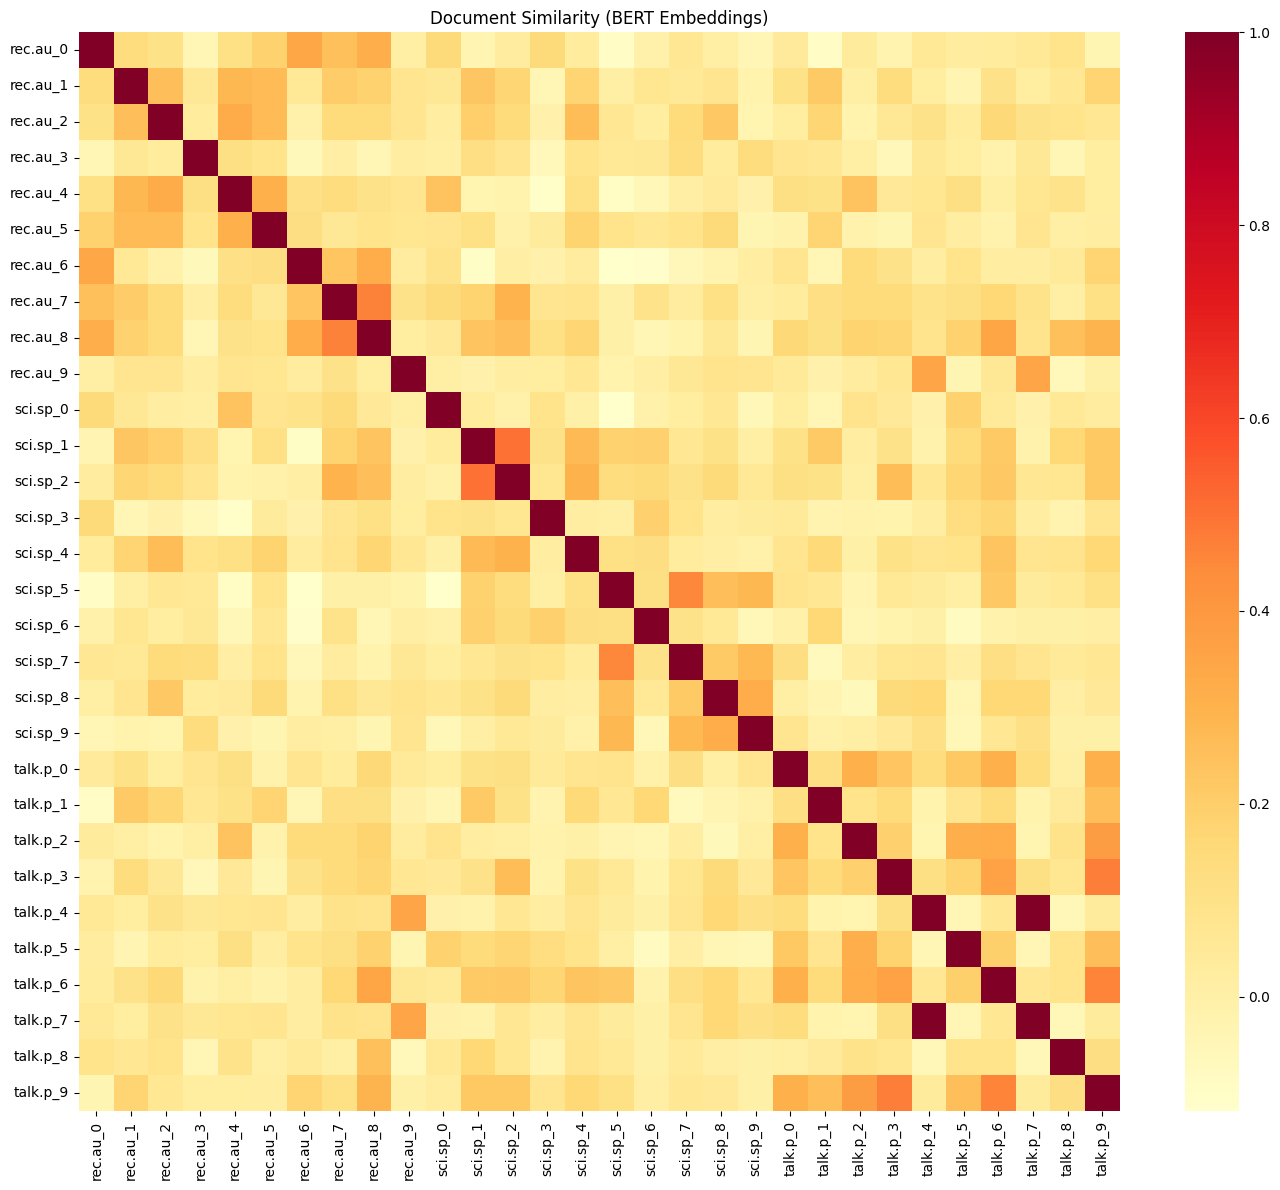

In [78]:
# Visualize BERT similarity matrix
import seaborn as sns

# Create labels
labels_short = [f"{l[:6]}_{i%10}" for i, l in enumerate(sampled_labels)]

plt.figure(figsize=(14, 12))
sns.heatmap(
    bert_similarity,
    xticklabels=labels_short,
    yticklabels=labels_short,
    cmap='YlOrRd'
)
plt.title('Document Similarity (BERT Embeddings)')
plt.tight_layout()
plt.savefig('bert_similarity_heatmap.png', dpi=150)
plt.show()

### Written Question C.1 (Personal Interpretation)

Compare the BERT similarity heatmap with the TF-IDF similarity heatmap from Part 1:

1. **Do documents cluster better by category with BERT or TF-IDF?**
2. **Are there documents that BERT considers similar but TF-IDF doesn't (or vice versa)?** Why might this happen?
3. **Which method would you use for a document classification task?** Explain your reasoning.

**YOUR ANSWER:**

1. Better clustering with: ...

2. Differences between methods: ...

3. Preferred method for classification: ...

### Exercise C.2: Semantic Search with BERT

In [79]:
# TODO: Create a simple semantic search function
# Given a query, find the most similar documents

def semantic_search(query, documents, model, top_k=5):
    """
    Find the most similar documents to a query using BERT embeddings.

    Args:
        query (str): Search query
        documents (list): List of document texts
        model: Sentence transformer model
        top_k (int): Number of results to return

    Returns:
        list: List of (index, similarity_score) tuples
    """
    # 1. Encode the query
    query_embedding = model.encode([query])

    # 2. Compute similarity with all documents
    # doc_embeddings was already computed in a previous cell
    # We need to make sure doc_embeddings is available in the scope.
    # For this function, we'll re-encode documents for simplicity if not globally available.
    # However, in this notebook, doc_embeddings is a global variable.

    # Assuming doc_embeddings from ME5xXdEHTbnZ is accessible
    similarities = cosine_similarity(query_embedding, doc_embeddings)[0]

    # 3. Return top_k most similar
    # Get indices of top_k similar documents
    top_indices = similarities.argsort()[-top_k:][::-1]

    results = []
    for idx in top_indices:
        results.append((idx, similarities[idx]))

    return results

# Test your search function
# TODO: Write a query related to ONE of your categories
my_query = "electric cars and vehicle efficiency"  # YOUR QUERY HERE - Example for 'rec.autos'

results = semantic_search(my_query, sampled_docs, sentence_model, top_k=5)

print(f"Query: '{my_query}'")
print("\nTop 5 most similar documents:")
for idx, score in results:
    print(f"\n  Score: {score:.4f}")
    print(f"  Category: {sampled_labels[idx]}")
    print(f"  Text: {sampled_docs[idx][:150]}...")

Query: 'electric cars and vehicle efficiency'

Top 5 most similar documents:

  Score: 0.2445
  Category: rec.autos
  Text: Dumbest options? Well here in the UK, BMW offer a 'no-smokers' option...
It just means they take the fag lighter out.... big deal....

BTW - I just bo...

  Score: 0.2224
  Category: rec.autos
  Text: 
no, but somebody's dropped a ford 302 V-8 into the miata, somewhat
reminiscent of the shelby cobra.  the car's obviously not as nimble
as before, but...

  Score: 0.2196
  Category: rec.autos
  Text: 
Ok, here's what I understand:

The SL/SL1/SL2/SW1/SW2 was meant to compete with the following cars:

Honda Civic
Toyota Tercel (SL,SL1)
Toyota Coroll...

  Score: 0.2084
  Category: rec.autos
  Text: For those that are interested I got my fully optioned (Air, ABS,
sunroof) '92 SE-R in September 1991 for $13,555 in Sacramento, CA. It
was one of the ...

  Score: 0.1520
  Category: sci.space
  Text: 
There was a recession, and none of the potential entrants could raise a

### Written Question C.2 (Personal Interpretation)

Evaluate your semantic search results:

1. **Are the results relevant to your query?** Explain.
2. **Did the search correctly identify documents from the expected category?**
3. **Try a query that could match multiple categories. What happens?**

**YOUR ANSWER:**

1. Relevance: ...

2. Category accuracy: ...

3. Ambiguous query test: ...

---

## Part D: Embedding Visualization with t-SNE

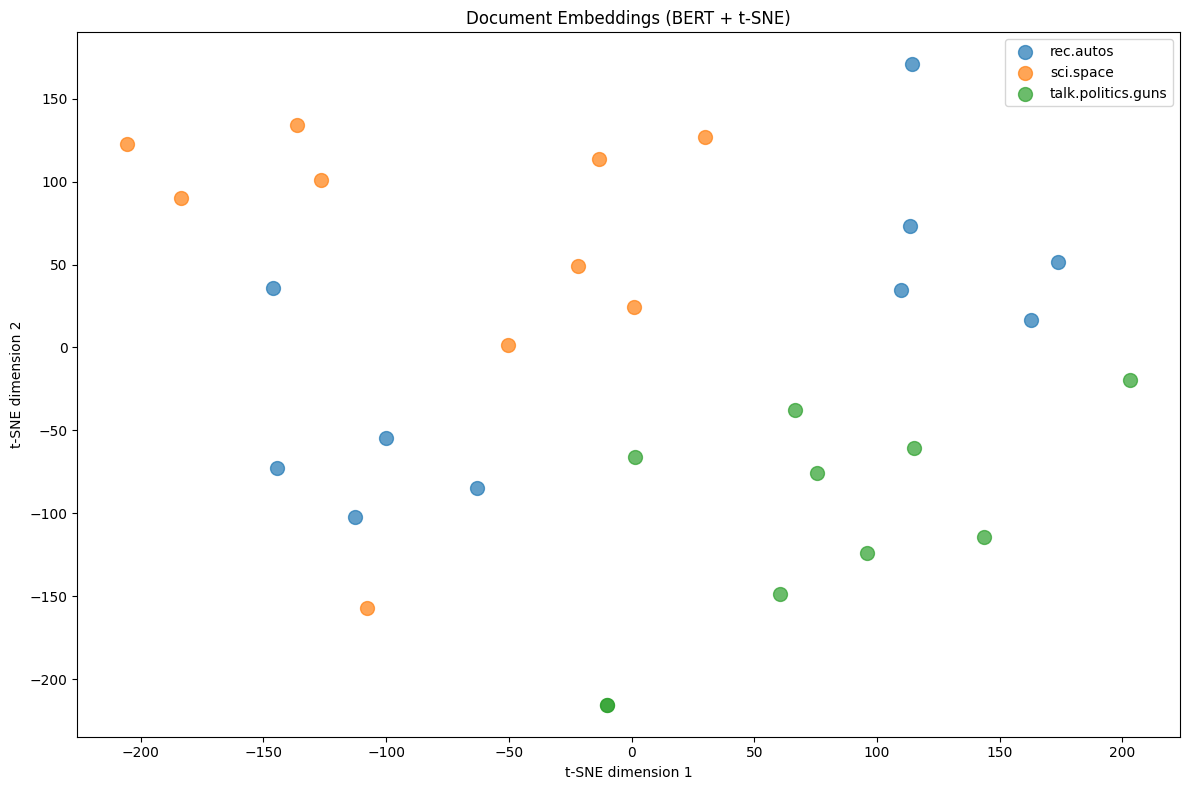

In [80]:
from sklearn.manifold import TSNE

# Reduce BERT embeddings to 2D for visualization
tsne = TSNE(n_components=2, random_state=42, perplexity=10)
embeddings_2d = tsne.fit_transform(doc_embeddings)

# Plot
plt.figure(figsize=(12, 8))

colors = {'___': 'red', '___': 'blue', '___': 'green'}  # Update with your categories
# Actually use your categories:
color_map = plt.cm.Set1

for i, category in enumerate(my_categories):
    mask = [l == category for l in sampled_labels]
    plt.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        label=category,
        alpha=0.7,
        s=100
    )

plt.legend()
plt.title('Document Embeddings (BERT + t-SNE)')
plt.xlabel('t-SNE dimension 1')
plt.ylabel('t-SNE dimension 2')
plt.tight_layout()
plt.savefig('tsne_document_embeddings.png', dpi=150)
plt.show()

### Written Question D.1 (Personal Interpretation)

Look at your t-SNE visualization:

1. **Do the categories form distinct clusters?**
2. **Are there any documents that appear in the "wrong" cluster?** What might explain this?
3. **Based on the visualization, which two categories are most similar?** Does this match your expectations from Part 1?

**YOUR ANSWER:**

1. Cluster quality: ...

2. Misplaced documents: ...

3. Most similar categories: ...

---

## Part E: Final Comparison and Reflection (10 min)

### Final Written Question (Comprehensive Reflection)

Based on everything you've learned in this lab:

1. **Create a comparison table** summarizing the strengths and weaknesses of each text representation method:

| Method | Strengths | Weaknesses | Best Use Case |
|--------|-----------|------------|---------------|
| BoW | ... | ... | ... |
| TF-IDF | ... | ... | ... |
| Word2Vec | ... | ... | ... |
| GloVe | ... | ... | ... |
| BERT | ... | ... | ... |

2. **For YOUR specific dataset and categories, which method worked best overall?** Support your answer with specific evidence from your experiments.

3. **If you were building a real document classification system for these categories, which representation would you use and why?**

**YOUR ANSWER:**

### 1. Comparison Table

| Method | Strengths | Weaknesses | Best Use Case |
|--------|-----------|------------|---------------|
| BoW | ... | ... | ... |
| TF-IDF | ... | ... | ... |
| Word2Vec | ... | ... | ... |
| GloVe | ... | ... | ... |
| BERT | ... | ... | ... |

### 2. Best Method for My Dataset

*[Write at least 4-5 sentences with specific evidence]*

...

### 3. My Recommendation for a Real System

*[Write your recommendation and justification]*

...

---

## Summary - Lab 3

In this lab, you learned:

**Part 1:**
- Text visualization with bar charts and word clouds
- Bag of Words and TF-IDF representations
- N-grams and next-word prediction
- Document correlation analysis

**Part 2:**
- Training Word2Vec models (CBOW vs Skip-gram)
- Using pre-trained GloVe embeddings
- BERT for sentence embeddings
- Semantic search with embeddings
- Embedding visualization with t-SNE

---